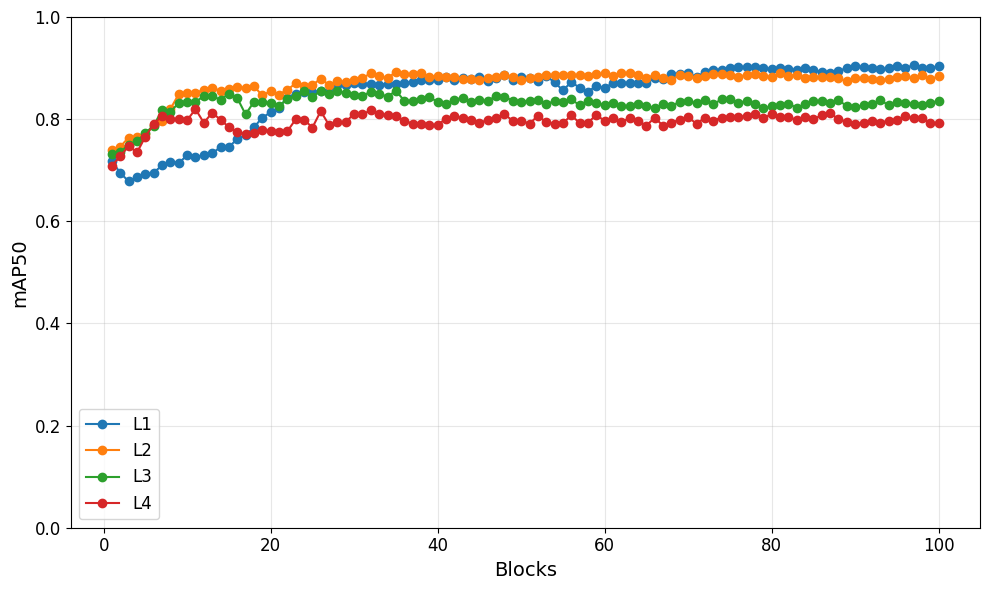

Saved plot: /home/paco/Proyectos/WAID/plots/map50_old_by_block.pdf


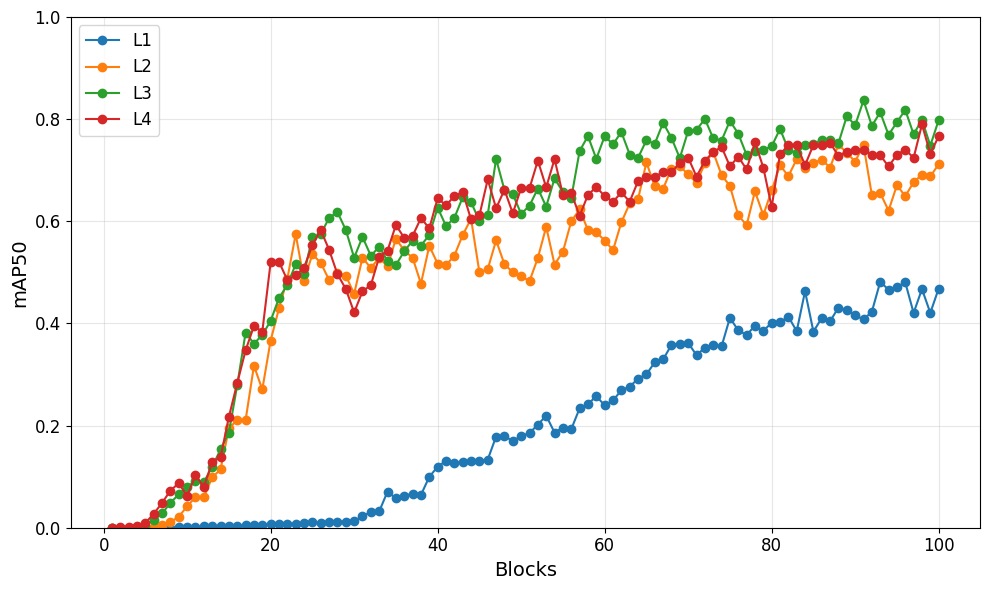

Saved plot: /home/paco/Proyectos/WAID/plots/map50_new_by_block.pdf


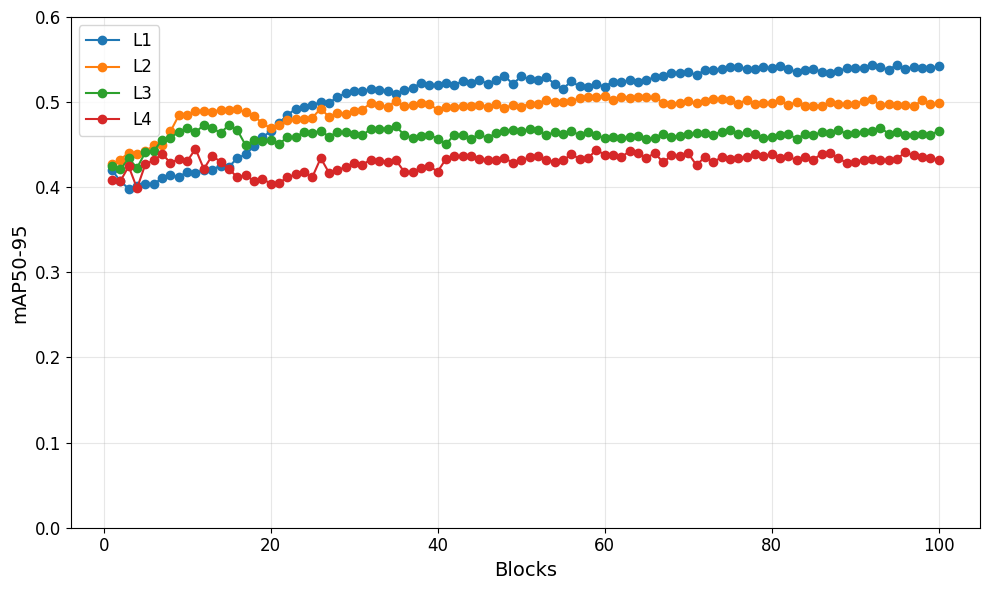

Saved plot: /home/paco/Proyectos/WAID/plots/map5095_old_by_block.pdf


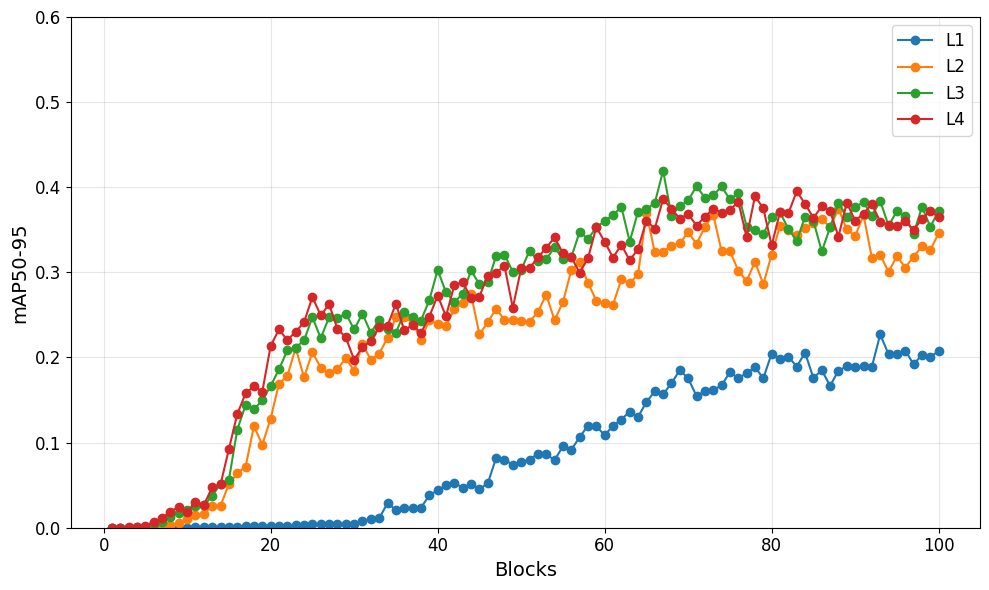

Saved plot: /home/paco/Proyectos/WAID/plots/map5095_new_by_block.pdf
[WARN] No confmat CSV for L1_B100 in /home/paco/Proyectos/WAID/logs/ValWAID+/confmat_full_L1_B100.csv
[WARN] No confmat CSV for L2_B100 in /home/paco/Proyectos/WAID/logs/ValWAID+/confmat_full_L2_B100.csv
[WARN] No confmat CSV for L3_B100 in /home/paco/Proyectos/WAID/logs/ValWAID+/confmat_full_L3_B100.csv
[WARN] No confmat CSV for L4_B100 in /home/paco/Proyectos/WAID/logs/ValWAID+/confmat_full_L4_B100.csv


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    # Si corre como script .py
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Si corre en Jupyter Notebook
    BASE_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, ".."))
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")
VAL_LOG_DIR = os.path.join(LOG_DIR, "ValWAID+")
PLOT_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

RUNS_DIR = os.path.join(PROJECT_ROOT, "runs", "ValWAID+")

OLD_CLASSES = {0, 1, 2, 3, 4, 5}
NEW_CLASSES = {6, 7, 8, 9}

LEVELS_WAIDPLUS = [1, 2, 3, 4]
MAX_BLOCKS = 100


def load_all_val_csv():
    rows = []
    for level in LEVELS_WAIDPLUS:
        for block in range(1, MAX_BLOCKS + 1):
            tag = f"L{level}_B{block}"
            csv_path = os.path.join(VAL_LOG_DIR, f"class_{tag}.csv")
            if not os.path.exists(csv_path):
                continue
            df = pd.read_csv(csv_path)
            df = df[df["class_id"].apply(lambda x: str(x).isdigit())].copy()
            df["class_id"] = df["class_id"].astype(int)
            df["level"] = level
            df["block"] = block
            rows.append(df)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def compute_group_maps(df):
    def cls_type(cid):
        if cid in OLD_CLASSES:
            return "old"
        elif cid in NEW_CLASSES:
            return "new"
        else:
            return "other"

    df = df.copy()
    df["cls_group"] = df["class_id"].apply(cls_type)
    df = df[df["cls_group"].isin(["old", "new"])]

    grp = df.groupby(["level", "block", "cls_group"], as_index=False).agg(
        mAP50=("mAP50", "mean"),
        mAP5095=("mAP50-95", "mean"),
    )
    return grp


def plot_metric_by_block(grp, metric, cls_group, out_path, ylabel,
                         ymin=None, ymax=None):
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    for level in LEVELS_WAIDPLUS:
        sub = grp[(grp["cls_group"] == cls_group) & (grp["level"] == level)]
        if sub.empty:
            continue
        sub = sub.sort_values("block")
        plt.plot(sub["block"], sub[metric], marker="o", label=f"L{level}")
    plt.xlabel("Blocks", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    if ymin is not None or ymax is not None:
        ax.set_ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    ax.tick_params(axis="both", labelsize=12)
    plt.tight_layout()
    plt.savefig(out_path, format="pdf")
    plt.show()
    plt.close()
    print("Saved plot:", out_path)


def find_last_block_with_csv(level):
    last_block = None
    for block in range(1, MAX_BLOCKS + 1):
        tag = f"L{level}_B{block}"
        csv_path = os.path.join(VAL_LOG_DIR, f"class_{tag}.csv")
        if os.path.exists(csv_path):
            last_block = block
    return last_block


def save_confmat_pdf_from_csv(level, cm_csv_path, class_names=None,
                              normalize_rows=True, out_suffix="full"):
    # lee matriz completa guardada desde model.val
    df_cm = pd.read_csv(cm_csv_path, header=None)
    cm = df_cm.values.astype(float)

    # opcional: normalizar por filas (proporciones)
    if normalize_rows:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm / row_sums
    else:
        cm_plot = cm

    n = cm_plot.shape[0]
    if class_names is None:
        # últimos índices para background/totales; cámbialo si quieres nombres
        class_names = [str(i) for i in range(n)]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_plot, interpolation="nearest",
                   cmap="Blues",
                   vmin=0.0 if normalize_rows else None,
                   vmax=1.0 if normalize_rows else None)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    fmt = ".2f" if normalize_rows else ".0f"
    thresh = (cm_plot.max() + cm_plot.min()) / 2.0
    for i in range(n):
        for j in range(n):
            val = cm_plot[i, j]
            ax.text(
                j, i,
                format(val, fmt),
                ha="center", va="center",
                fontsize=10,
                color="white" if val > thresh else "black",
            )

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout(pad=0.1)
    out_pdf = os.path.join(PLOT_DIR, f"confmat_{out_suffix}_L{level}.pdf")
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.0)
    plt.show()
    plt.close(fig)
    print(f"Saved confusion matrix PDF for L{level} -> {out_pdf}")


def save_confmat_pdf_for_last_block(level):
    last_block = find_last_block_with_csv(level)
    if last_block is None:
        print(f"[SKIP] No CSVs found for level L{level}")
        return

    tag = f"L{level}_B{last_block}"

    # matriz completa (clases + background/totales) guardada por WAID+Valid
    cm_csv_path = os.path.join(VAL_LOG_DIR, f"confmat_full_{tag}.csv")
    if not os.path.exists(cm_csv_path):
        print(f"[WARN] No confmat CSV for {tag} in {cm_csv_path}")
        return

    # si quieres nombrar la última fila/columna:
    # class_names = ["sheep","cattle","seal","camelus","kiang",
    #                "zebra","crocodile","elephant","deer","horse","background"]
    class_names = None

    # normalizada por filas
    save_confmat_pdf_from_csv(
        level,
        cm_csv_path,
        class_names=class_names,
        normalize_rows=True,
        out_suffix="fullnorm",
    )

    # opcional: versión sin normalizar (conteos brutos)
    # save_confmat_pdf_from_csv(
    #     level,
    #     cm_csv_path,
    #     class_names=class_names,
    #     normalize_rows=False,
    #     out_suffix="fullcounts",
    # )


def main():
    df = load_all_val_csv()
    if df.empty:
        print("No validation CSVs found in", VAL_LOG_DIR)
        return

    grp = compute_group_maps(df)

    # mAP50 (0–1)
    plot_metric_by_block(
        grp,
        metric="mAP50",
        cls_group="old",
        out_path=os.path.join(PLOT_DIR, "map50_old_by_block.pdf"),
        ylabel="mAP50",
        ymin=0.0,
        ymax=1.0,
    )

    plot_metric_by_block(
        grp,
        metric="mAP50",
        cls_group="new",
        out_path=os.path.join(PLOT_DIR, "map50_new_by_block.pdf"),
        ylabel="mAP50",
        ymin=0.0,
        ymax=1.0,
    )

    # mAP50-95 (0–0.6)
    plot_metric_by_block(
        grp,
        metric="mAP5095",
        cls_group="old",
        out_path=os.path.join(PLOT_DIR, "map5095_old_by_block.pdf"),
        ylabel="mAP50-95",
        ymin=0.0,
        ymax=0.6,
    )

    plot_metric_by_block(
        grp,
        metric="mAP5095",
        cls_group="new",
        out_path=os.path.join(PLOT_DIR, "map5095_new_by_block.pdf"),
        ylabel="mAP50-95",
        ymin=0.0,
        ymax=0.6,
    )

    # Confusion matrices para el último bloque de cada nivel
    for level in LEVELS_WAIDPLUS:
        save_confmat_pdf_for_last_block(level)


if __name__ == "__main__":
    main()
